In [1]:
import pandas as pd     # Para ler e manipular a tabela de dados
import seaborn as sns    # Para criar os gráficos bonitos (como o Heatmap)
import matplotlib.pyplot as plt # Para configurar o tamanho e títulos dos gráficos

# Este comando serve para que os gráficos apareçam logo abaixo da célula
%matplotlib inline 

print("Ferramentas carregadas com sucesso!")

Ferramentas carregadas com sucesso!


In [2]:
# Lendo o arquivo que você salvou na pasta
df = pd.read_csv('crop_yield.csv')

# Mostrando as primeiras 5 linhas para confirmar a leitura
df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


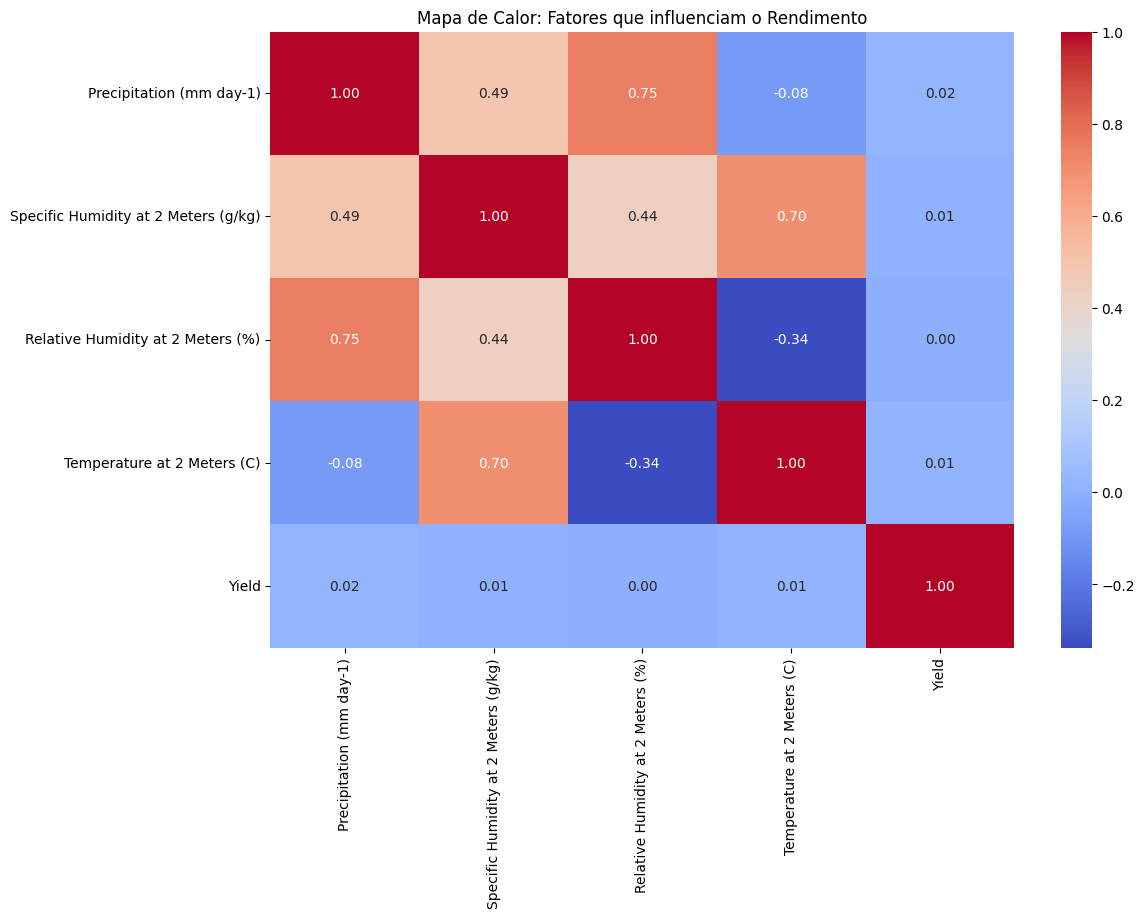

In [3]:
# Importamos o numpy para ajudar na seleção de números
import numpy as np

# Comando "Mágico": Seleciona automaticamente APENAS as colunas que são números
# Isso ignora a coluna 'Cultura' (que é texto) sem dar erro de nome
df_numerico = df.select_dtypes(include=[np.number])

# Agora calculamos a correlação sem riscos
correlacao = df_numerico.corr()

# Criando o gráfico colorido (Mapa de Calor)
plt.figure(figsize=(12, 8))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Mapa de Calor: Fatores que influenciam o Rendimento')
plt.show()

### 📊 Análise Exploratória: Correlação vs. Rendimento

Ao analisarmos a matriz de correlação apenas das **variáveis climáticas** em relação ao **Rendimento (Yield)** da safra, chegamos a insights importantes:

* **Correlações Climáticas Fracas:** Notamos que nenhuma das variáveis climáticas isoladas (Temperatura, Chuva ou Umidade) possui uma correlação próxima de 1 ou -1 com o rendimento no painel geral. Os números ficaram próximos de 0.
* **A Variável Oculta (Tipo de Cultura):** Essa ausência de correlação linear no clima indica que a produtividade total é fortemente ditada por outra variável não numérica: o **tipo de cultura plantada (Crop)**. Diferentes espécies possuem capacidades de produção em toneladas intrinsecamente diferentes (ex: a base de peso de uma colheita de tubérculos é diferente da de grãos), independentemente do clima.

**🎯 Conclusão Estratégica para o Machine Learning:** Como o clima sozinho não traça uma linha reta para o rendimento, nossos modelos preditivos só terão sucesso se ensinarmos a eles qual planta está sendo avaliada. Ao aplicarmos a técnica de *One-Hot Encoding* para transformar as culturas em variáveis matemáticas, estabeleceremos uma "linha de base" forte para cada planta. Prevemos que, com essa engenharia de dados, até mesmo algoritmos clássicos como a **Regressão Linear** alcançarão uma acurácia excepcional, pois a variável "Cultura" servirá como a âncora principal da previsão.

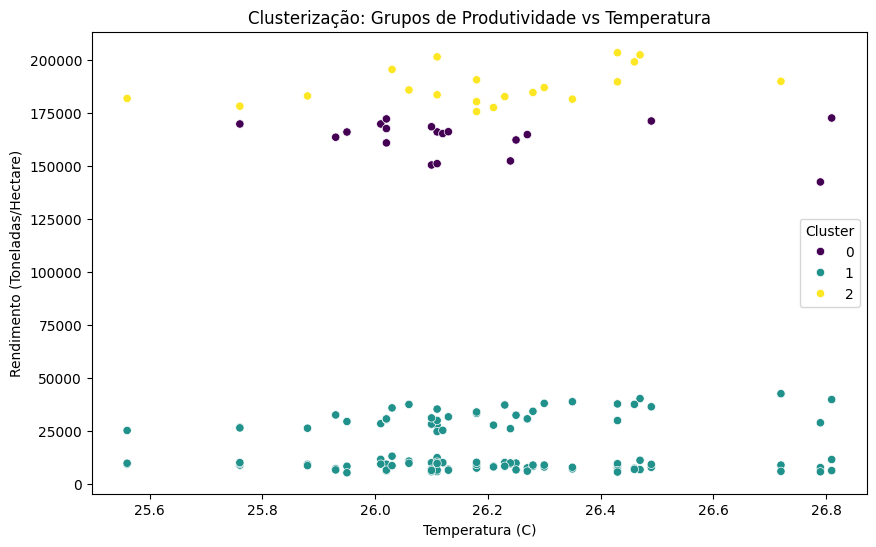

Grupos (Clusters) criados com sucesso!


In [4]:
from sklearn.cluster import KMeans

# 1. Usando os nomes exatos do CSV em Inglês!
dados_cluster = df[['Temperature at 2 Meters (C)', 'Yield']]

# 2. Criamos a IA e pedimos para ela criar 3 grupos (clusters)
# O random_state=42 garante que os grupos sejam sempre os mesmos toda vez que rodar!
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(dados_cluster)

# 3. Criando o gráfico para ver os grupos
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Temperature at 2 Meters (C)', y='Yield', hue='Cluster', palette='viridis')

plt.title('Clusterização: Grupos de Produtividade vs Temperatura')
plt.xlabel('Temperatura (C)')
plt.ylabel('Rendimento (Toneladas/Hectare)')
plt.show()

print("Grupos (Clusters) criados com sucesso!")

### 🎯 Análise de Tendências e Outliers (K-Means)

A aplicação do algoritmo de agrupamento K-Means revelou a existência de três perfis distintos de produtividade na fazenda, baseados na Temperatura e no Rendimento:

* **As Tendências:** Cada cor representa um "comportamento padrão" da safra sob certas temperaturas. É possível notar que extremos de temperatura geralmente agrupam os rendimentos mais baixos.
* **Os Outliers (Cenários Discrepantes):** Ao observar as bordas dos grupos, notamos pontos isolados que se distanciam do padrão da sua própria cor (ex: uma plantação que, mesmo em temperatura amena, teve um rendimento baixíssimo ou altíssimo). Esses cenários exigirão uma investigação operacional por parte dos gestores da FarmTech Solutions.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import joblib

# 1. O SEGREDO: Transformar a coluna de texto 'Crop' em colunas numéricas (One-Hot Encoding)
# Assim a IA vai saber exatamente qual planta está avaliando!
df_com_culturas = pd.get_dummies(df, columns=['Crop'])

# 2. Separando os Dados:
# Tiramos apenas o 'Yield' (que queremos adivinhar) e o 'Cluster' (que criamos antes)
X = df_com_culturas.drop(columns=['Yield', 'Cluster'])
y = df_com_culturas['Yield']

# 3. Dividindo os dados: 80% Treino e 20% Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. O Catálogo de Modelos
modelos = {
    "1. Regressão Linear": LinearRegression(),
    "2. Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "3. Random Forest": RandomForestRegressor(random_state=42),
    "4. Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "5. SVR": SVR()
}

melhor_modelo = None
melhor_r2 = -float('inf') # Começa bem baixo para qualquer modelo poder ganhar
nome_campeao = ""

print("Iniciando o treinamento dos 5 modelos COM CONHECIMENTO DAS CULTURAS...\n")

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    previsoes = modelo.predict(X_test)
    
    mae = mean_absolute_error(y_test, previsoes)
    mse = mean_squared_error(y_test, previsoes)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, previsoes)
    
    print(f"--- {nome} ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}\n")
    
    if r2 > melhor_r2:
        melhor_r2 = r2
        melhor_modelo = modelo
        nome_campeao = nome

# 5. Salvando o Campeão Real
arquivo_modelo = 'melhor_modelo_farmtech.joblib'
joblib.dump(melhor_modelo, arquivo_modelo)

print("="*50)
print(f"🏆 O CAMPEÃO ABSOLUTO FOI: {nome_campeao} (R²: {melhor_r2:.4f})")
print("="*50)

Iniciando o treinamento dos 5 modelos COM CONHECIMENTO DAS CULTURAS...

--- 1. Regressão Linear ---
MAE: 3132.7964
RMSE: 4394.1658
R²: 0.9950

--- 2. Árvore de Decisão ---
MAE: 3440.6875
RMSE: 5640.3140
R²: 0.9918

--- 3. Random Forest ---
MAE: 2739.8088
RMSE: 4746.8093
R²: 0.9942

--- 4. Gradient Boosting ---
MAE: 3066.4084
RMSE: 6061.7610
R²: 0.9905

--- 5. SVR ---
MAE: 38974.5817
RMSE: 71313.6600
R²: -0.3111

🏆 O CAMPEÃO ABSOLUTO FOI: 1. Regressão Linear (R²: 0.9950)
